# Black-Scholes Option Pricing via Crank-Nicolson Finite Differences

## Problem

Price a European call option `V(S,t)` under the Black-Scholes PDE

```
∂V/∂t + ½σ²S²∂²V/∂S² + rS∂V/∂S − rV = 0
```

given volatility `σ`, risk-free rate `r`, strike `K`, and time to maturity `T`, on a non-uniform
spatial grid `S_i = S_max·(i/N)²` that concentrates nodes near `S=0`.

## Method

The spatial operator `L(V) = ½σ²S²∂²V/∂S² + rS∂V/∂S − rV` is discretized with central differences
on the non-uniform grid, giving a tridiagonal operator `L(V)_i = α_i V_{i-1} + β_i V_i + γ_i V_{i+1}`.
Time-stepping uses **Crank-Nicolson**: the spatial operator is averaged between the old and new time
level,

```
V^{n+1} − (Δt/2)·L(V^{n+1}) = V^n + (Δt/2)·L(V^n)
```

which is solved as a tridiagonal linear system at every step (Dirichlet boundary rows pinned to their
known values). Unlike an explicit scheme — whose time step is capped by a stability limit
`Δt < h_{i-1}h_i / (r h_{i-1} h_i + σ² S_i²)` — Crank-Nicolson is unconditionally stable, so a much
larger time step can be used safely; this notebook uses a step ten times past the explicit limit.

Explicit stability limit: dt_max=0.017757 (57 steps); Crank-Nicolson uses dt=0.166667 (6 steps, unconditionally stable).


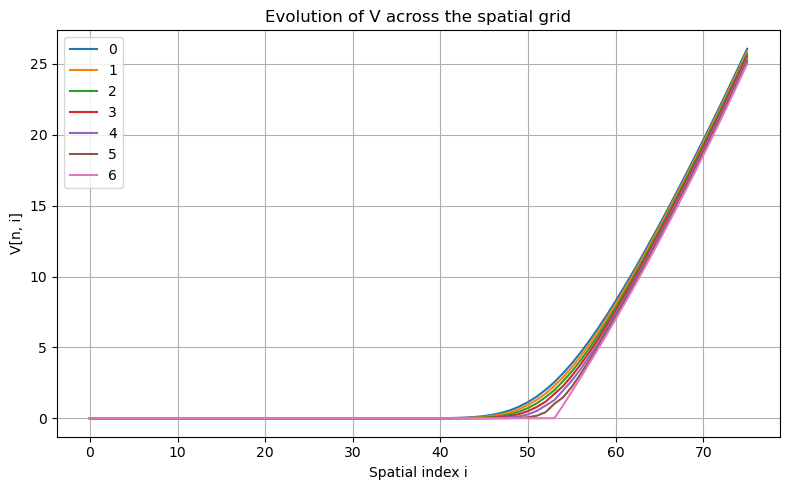

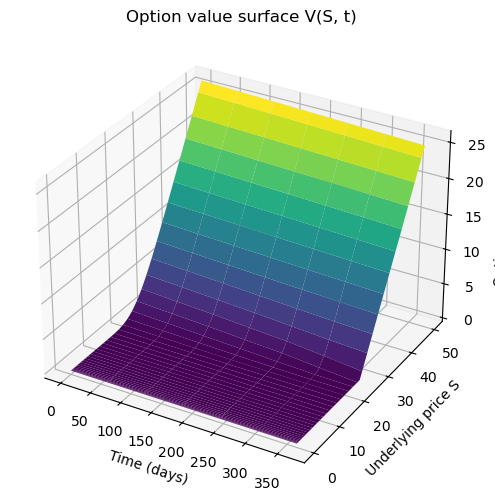

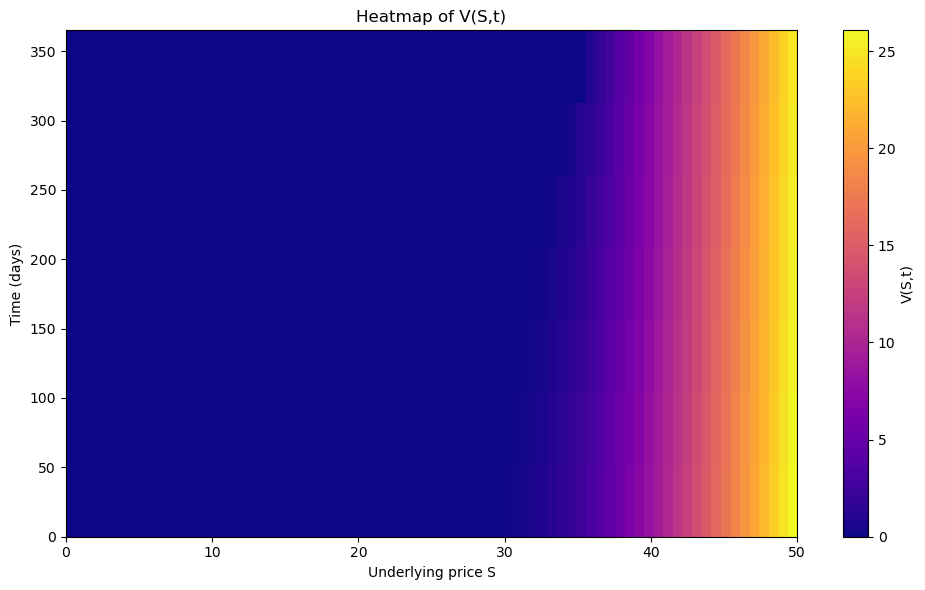


Option values at t = 0:
Price S         Value V(S,0)        
-----------------------------------
0.0000          0.000000            
0.0089          0.000000            
0.0356          0.000000            
0.0800          0.000000            
0.1422          0.000000            
0.2222          0.000000            
0.3200          0.000000            
0.4356          0.000000            
0.5689          0.000000            
0.7200          0.000000            
0.8889          0.000000            
1.0756          0.000000            
1.2800          0.000000            
1.5022          0.000000            
1.7422          0.000000            
2.0000          0.000000            
2.2756          0.000000            
2.5689          0.000000            
2.8800          0.000000            
3.2089          0.000000            
3.5556          0.000000            
3.9200          0.000000            
4.3022          0.000000            
4.7022          0.000000            
5.1200        

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import solve_banded

# Parameters (edit these to price a different contract)
K = 25.0        # strike
Smax = 50.0     # upper truncation of the underlying-price grid
N = 75          # number of spatial grid points
sigma = 0.20    # volatility
r = 0.0436      # risk-free rate
T = 1.0         # time to maturity, in years

# Non-uniform spatial grid (quadratic grading, denser near S=0)
S = np.array([Smax * (i / N)**2 for i in range(N + 1)])
h = np.zeros(N + 1)
for i in range(1, N + 1):
    h[i] = max(S[i] - S[i - 1], 1e-8)
h[0] = h[1]

# Crank-Nicolson is unconditionally stable, so the time step is no longer capped by
# the explicit scheme's stability limit dt < h[i-1]*h[i] / (r*h[i-1]*h[i] + sigma^2*S[i]^2).
# We use a step an order of magnitude larger than that limit.
dt_explicit_max = np.min([(h[i - 1] * h[i]) / (r * h[i - 1] * h[i] + sigma**2 * S[i]**2)
                          for i in range(1, N)])
dt = 10.0 * dt_explicit_max
M = int(np.ceil(T / dt))
dt = T / M  # exact step so M steps land exactly on T
print(f"Explicit stability limit: dt_max={dt_explicit_max:.6f} ({int(np.ceil(T/dt_explicit_max))} steps); "
      f"Crank-Nicolson uses dt={dt:.6f} ({M} steps, unconditionally stable).")

# Discrete spatial operator L(V)_i = alpha_i*V_{i-1} + beta_i*V_i + gamma_i*V_{i+1},
# approximating (1/2) sigma^2 S^2 d2V/dS2 + r S dV/dS - r V on the non-uniform grid
alpha = np.zeros(N + 1)
beta = np.zeros(N + 1)
gamma = np.zeros(N + 1)
for i in range(1, N):
    hi, him1, xi = h[i], h[i - 1], S[i]
    alpha[i] = (sigma**2 * xi**2 - r * xi * him1) / (him1 * (him1 + hi))
    beta[i] = -r - sigma**2 * xi**2 / (him1 * hi)
    gamma[i] = (sigma**2 * xi**2 + r * xi * hi) / (hi * (him1 + hi))

# V[n, i]: option value at time step n (n=0 -> t=0 today, n=M -> t=T maturity)
V = np.zeros((M + 1, N + 1))
V[M, :] = np.maximum(S - K, 0.0)  # terminal payoff (call) at t=T

def lower_boundary(t):
    return 0.0

def upper_boundary(t):
    return Smax - K * np.exp(-r * (T - t))

for n in range(M + 1):
    t = n * dt
    V[n, 0] = lower_boundary(t)
    V[n, N] = upper_boundary(t)

# Crank-Nicolson: average the spatial operator at the known level (n+1, closer to
# maturity) and the unknown level (n, earlier), stepping backward from n=M to n=0:
#   V^n - (dt/2) L(V^n) = V^{n+1} + (dt/2) L(V^{n+1})
# The left-hand side is a fixed tridiagonal system in the unknown V^n; boundary rows
# are pinned to their known Dirichlet values instead of using the interior stencil.
lower_diag = np.zeros(N + 1)
main_diag = np.zeros(N + 1)
upper_diag = np.zeros(N + 1)
for i in range(1, N):
    lower_diag[i] = -0.5 * dt * alpha[i]
    main_diag[i] = 1.0 - 0.5 * dt * beta[i]
    upper_diag[i] = -0.5 * dt * gamma[i]
main_diag[0] = main_diag[N] = 1.0  # boundary rows: identity

ab = np.zeros((3, N + 1))
ab[0, 1:] = upper_diag[:-1]   # super-diagonal, scipy banded-storage convention
ab[1, :] = main_diag          # main diagonal
ab[2, :-1] = lower_diag[1:]   # sub-diagonal, scipy banded-storage convention

# alpha, beta, gamma are fixed in n (the coefficients depend only on the spatial
# grid S, not on time), so the interior of the right-hand side is a single vectorized
# NumPy expression per step rather than an explicit length-N Python loop: this removes
# an O(N) Python-level loop from the innermost part of an O(M) time-stepping loop,
# replacing O(M*N) interpreted operations with O(M) vectorized NumPy calls.
interior = slice(1, N)
rhs = np.empty(N + 1)
for n in range(M - 1, -1, -1):
    rhs[interior] = (0.5 * dt * alpha[interior] * V[n + 1, 0:N - 1]
                      + (1.0 + 0.5 * dt * beta[interior]) * V[n + 1, 1:N]
                      + 0.5 * dt * gamma[interior] * V[n + 1, 2:N + 1])
    rhs[0] = V[n, 0]
    rhs[N] = V[n, N]
    V[n, :] = solve_banded((1, 1), ab, rhs)

# --- Save output and plot ---

pd.DataFrame(V).to_csv("black_scholes_grid_index.csv", index=False, header=False)

df_real = pd.DataFrame(V)
df_real.insert(0, "t(days)", np.linspace(0, T * 365, M + 1))
df_real.columns = ["t(days)"] + list(S)
df_real.to_csv("black_scholes_grid_S_t.csv", index=False)

# Plot 1: V[i] curves over time
plt.figure(figsize=(8, 5))
for n in range(0, V.shape[0], max(1, V.shape[0] // 20)):
    plt.plot(V[n], label=f"{n}")
plt.title("Evolution of V across the spatial grid")
plt.xlabel("Spatial index i")
plt.ylabel("V[n, i]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("black_scholes_grid_evolution.png")
plt.show()

# Plot 2: V(S,t) surface
t_values = np.linspace(0, T * 365, M + 1)
t_grid, S_grid = np.meshgrid(t_values, S, indexing='ij')
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(t_grid, S_grid, V, cmap='viridis')
ax.set_title("Option value surface V(S, t)")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Underlying price S")
ax.set_zlabel("Option value V(S,t)")
plt.show()

# Plot 3: heatmap
plt.figure(figsize=(10, 6))
plt.imshow(V, aspect='auto', origin='lower', extent=[S.min(), S.max(), 0, T * 365], cmap='plasma')
plt.colorbar(label='V(S,t)')
plt.title("Heatmap of V(S,t)")
plt.xlabel("Underlying price S")
plt.ylabel("Time (days)")
plt.tight_layout()
plt.savefig("black_scholes_heatmap.png")
plt.show()

# Table of option values at t=0
print("\nOption values at t = 0:")
print("{:<15} {:<20}".format("Price S", "Value V(S,0)"))
print("-" * 35)
for i in range(N + 1):
    print("{:<15.4f} {:<20.6f}".format(S[i], V[0][i]))
